# Keras RNN forecast for VIX log returns

This notebook mirrors the data loading and lagged exogenous-variable processing from `arima.ipynb`, adds leakage-safe S&P 500 inputs, and trains a Keras GRU on walk-forward sequence windows.

In [ ]:
import random

import numpy as np
import pandas as pd
try:
    import yahooquery as yq
except ImportError:
    yq = None

try:
    import yfinance as yf
except ImportError:
    yf = None

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")

## Load and Prep Data

These cells intentionally match the source data and base preprocessing in `arima.ipynb`: Reddit daily sentiment, daily GPR indexes, Yahoo VIX prices, an inner merge through `dropna`, and close-to-close VIX log returns. The S&P 500 data is downloaded from the same Yahoo source family and shifted before modeling so the RNN only sees market information available before the VIX close being predicted.

In [ ]:
sentiment_df = pd.read_csv("../data/daily-sentiment-comments.csv").rename(columns={"created_date": "date"})
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])
sentiment_df.sample(5, random_state=RANDOM_SEED)

In [ ]:
# https://www.matteoiacoviello.com/gpr.htm
# GPRD - Daily GPR (Index: 1985:2019=100)
# GPRD_ACT - Daily GPR Acts (Index: 1985:2019=100)
# GPRD_THREAT - Daily GPR Threats (Index: 1985:2019=100)
gpr_df = pd.read_stata("../data/gpr_daily.dta", columns=["date", "GPRD", "GPRD_ACT", "GPRD_THREAT"])
gpr_df.head()

In [ ]:
def flatten_yahoo_columns(frame):
    out = frame.copy()
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = [str(col[0]).lower().replace(" ", "") for col in out.columns]
    else:
        out.columns = [str(col).lower().replace(" ", "") for col in out.columns]
    return out


def load_yahoo_adjclose(symbol, start="2012-01-01", end="2026-01-01"):
    if yq is not None:
        hist = yq.Ticker(symbol).history(interval="1d", start=start, end=end).reset_index()
        hist["date"] = pd.to_datetime(hist["date"])
        return hist[["date", "adjclose"]].copy()

    if yf is None:
        raise ImportError("Install yahooquery or yfinance to download market history.")

    hist = yf.download(symbol, start=start, end=end, progress=False, auto_adjust=False).reset_index()
    hist = flatten_yahoo_columns(hist)
    hist["date"] = pd.to_datetime(hist["date"])
    return hist[["date", "adjclose"]].copy()


vix = load_yahoo_adjclose("^VIX")
sp500 = load_yahoo_adjclose("^GSPC").rename(columns={"adjclose": "sp500_adjclose"})

vix.head()

In [ ]:
# Merge VIX, S&P 500, sentiment, and GPR. The VIX/sentiment/GPR path mirrors arima.ipynb;
# S&P 500 is added as an additional market input and shifted below before modeling.
df = (
    vix
    .merge(sp500, on="date", how="left")
    .merge(sentiment_df, on="date", how="left")
    .merge(gpr_df, on="date", how="left")
    .dropna()
)
df = df.sort_values("date").reset_index(drop=True)

# Add close-to-close VIX and S&P 500 log returns.
df["log_return"] = np.log(df["adjclose"]).diff()
df["sp500_log_return"] = np.log(df["sp500_adjclose"]).diff()
df = df.dropna()

# These columns are contemporaneous in the raw merge, so match arima.ipynb
# by shifting them back one row before modeling.
for col in ["GPRD_THREAT", "GPRD_ACT", "GPRD", "final_score"]:
    df[f"{col}_lag1"] = df[col].shift(1)

# Add explicit lagged market levels and returns. The lookback window already
# contains prior rows, but these make the exact short-horizon lags visible to
# the model at each sequence step.
MARKET_LAGS = [1, 2, 5, 10]
for lag in MARKET_LAGS:
    df[f"vix_log_return_lag{lag}"] = df["log_return"].shift(lag)
    df[f"vix_adjclose_lag{lag}"] = df["adjclose"].shift(lag)
    df[f"sp500_log_return_lag{lag}"] = df["sp500_log_return"].shift(lag)
    df[f"sp500_adjclose_lag{lag}"] = df["sp500_adjclose"].shift(lag)

df = df.dropna().reset_index(drop=True)
df.head()

## Sequence Features

The RNN predicts one trading day at a time. Each target uses a lookback window ending on that target date, but all target-history and market features are shifted one row so the model only sees information available before the close being predicted.

In [ ]:
def build_rolling_features(series: pd.Series, prefix="") -> pd.DataFrame:
    # Same rolling windows used in arima.ipynb.
    out = pd.DataFrame(index=series.index)
    for window, label in [(21, "3w"), (42, "6w"), (365, "1y")]:
        out[f"{prefix}{label}_rolling_mean"] = series.rolling(window, min_periods=window).mean()
        out[f"{prefix}{label}_rolling_std"] = series.rolling(window, min_periods=window).std()
    return out

TARGET_COL = "log_return"
EXOG_COLS = [
    "GPRD_THREAT_lag1",
    "GPRD_ACT_lag1",
    "GPRD_lag1",
    "final_score_lag1",
]
MARKET_LAG_COLS = []
for lag in MARKET_LAGS:
    MARKET_LAG_COLS.extend([
        f"vix_log_return_lag{lag}",
        f"vix_adjclose_lag{lag}",
        f"sp500_log_return_lag{lag}",
        f"sp500_adjclose_lag{lag}",
    ])

model_df = df.copy()
vix_rolling = build_rolling_features(model_df[TARGET_COL].shift(1), prefix="vix_")
sp500_rolling = build_rolling_features(model_df["sp500_log_return"].shift(1), prefix="sp500_")
model_df = pd.concat([model_df, vix_rolling, sp500_rolling], axis=1).dropna().reset_index(drop=True)

ROLLING_COLS = list(vix_rolling.columns) + list(sp500_rolling.columns)
FEATURE_COLS = EXOG_COLS + MARKET_LAG_COLS + ROLLING_COLS

print(f"Rows available for RNN: {len(model_df):,}")
print(f"Date range: {model_df['date'].min().date()} to {model_df['date'].max().date()}")
print(f"Feature count: {len(FEATURE_COLS)}")
model_df[["date", TARGET_COL, *FEATURE_COLS]].head()

## Keras Dataset and Model

In [61]:
LOOKBACK_DAYS = 20
BATCH_SIZE = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.0
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 75
PATIENCE = 10

N_SPLITS = 10
TEST_SIZE = 200
VALIDATION_SIZE = 200

In [62]:
def eligible_target_indices(indices, lookback_days):
    return [int(idx) for idx in indices if int(idx) >= lookback_days - 1]


def split_train_validation(train_target_indices, validation_size=VALIDATION_SIZE):
    train_target_indices = list(train_target_indices)
    if len(train_target_indices) <= validation_size + 1:
        validation_size = max(1, len(train_target_indices) // 5)
    return train_target_indices[:-validation_size], train_target_indices[-validation_size:]


def build_sequence_arrays(frame, target_indices, feature_cols, target_col, feature_scaler, target_scaler, lookback_days):
    raw_features = frame[feature_cols].astype(np.float32)
    raw_targets = frame[[target_col]].astype(np.float32)
    features = feature_scaler.transform(raw_features).astype(np.float32)
    targets_scaled = target_scaler.transform(raw_targets).reshape(-1).astype(np.float32)
    targets_raw = raw_targets.to_numpy(dtype=np.float32).reshape(-1)

    x, y, y_raw, kept_indices = [], [], [], []
    for target_idx in target_indices:
        target_idx = int(target_idx)
        start_idx = target_idx - lookback_days + 1
        if start_idx < 0:
            continue
        x.append(features[start_idx:target_idx + 1])
        y.append(targets_scaled[target_idx])
        y_raw.append(targets_raw[target_idx])
        kept_indices.append(target_idx)

    return (
        np.asarray(x, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(y_raw, dtype=np.float32),
        np.asarray(kept_indices, dtype=int),
    )


def make_arrays_for_fold(train_idx, test_idx):
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    train_target_indices = eligible_target_indices(train_idx, LOOKBACK_DAYS)
    test_target_indices = eligible_target_indices(test_idx, LOOKBACK_DAYS)
    fit_target_indices, val_target_indices = split_train_validation(train_target_indices)

    scaler_fit_idx = train_idx[train_idx <= max(fit_target_indices)]
    feature_scaler = StandardScaler().fit(model_df.iloc[scaler_fit_idx][FEATURE_COLS])
    target_scaler = StandardScaler().fit(model_df.iloc[fit_target_indices][[TARGET_COL]])

    train_arrays = build_sequence_arrays(
        model_df, fit_target_indices, FEATURE_COLS, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    val_arrays = build_sequence_arrays(
        model_df, val_target_indices, FEATURE_COLS, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    test_arrays = build_sequence_arrays(
        model_df, test_target_indices, FEATURE_COLS, TARGET_COL, feature_scaler, target_scaler, LOOKBACK_DAYS
    )
    fold_indices = {
        "fit_target_indices": np.asarray(fit_target_indices, dtype=int),
        "val_target_indices": np.asarray(val_target_indices, dtype=int),
        "test_target_indices": np.asarray(test_target_indices, dtype=int),
        "scaler_fit_indices": np.asarray(scaler_fit_idx, dtype=int),
    }
    return train_arrays, val_arrays, test_arrays, target_scaler, fold_indices


def build_keras_rnn(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for layer_idx in range(NUM_LAYERS):
        return_sequences = layer_idx < NUM_LAYERS - 1
        x = layers.GRU(
            HIDDEN_SIZE,
            return_sequences=return_sequences,
            dropout=DROPOUT,
            recurrent_dropout=0.0,
        )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(HIDDEN_SIZE // 2, activation="gelu")(x)
    if DROPOUT > 0:
        x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(1)(x)

    try:
        optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss="mse")
    return model


def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=np.float64)
    predicted = np.asarray(predicted, dtype=np.float64)
    metrics = {
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }
    if np.any(actual != 0):
        metrics["directional_accuracy"] = float(np.mean(np.sign(actual) == np.sign(predicted)))
    else:
        metrics["directional_accuracy"] = np.nan
    return metrics


def evaluate_predictions(pred_scaled, y_raw, target_indices, target_scaler):
    pred_raw = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    out = pd.DataFrame({
        "target_index": target_indices,
        "date": model_df.iloc[target_indices]["date"].to_numpy(),
        "actual": y_raw,
        "predicted": pred_raw,
    })
    metrics = regression_metrics(out["actual"], out["predicted"])
    return metrics, out

## Walk-Forward Evaluation

This uses the same `TimeSeriesSplit(n_splits=6, test_size=20)` setup as `arima.ipynb`. The scaler is fit on each fold's training rows only; test sequences may use prior observed returns through yesterday, matching a one-day-ahead walk-forward forecast.

Epoch 1/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.5782 - val_loss: 2.1606
Epoch 2/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0629 - val_loss: 1.7707
Epoch 3/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8676 - val_loss: 1.7091
Epoch 4/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7675 - val_loss: 1.6619
Epoch 5/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7145 - val_loss: 1.6657
Epoch 6/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6574 - val_loss: 1.6714
Epoch 7/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6211 - val_loss: 1.6934
Epoch 8/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5842 - val_loss: 1.7108
Epoch 9/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5495 - val_loss: 1.7300
Epoch 10/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5194 - val_loss: 1.7586
Epoch 11/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4890 - val_loss: 1.7869
Epoch 12/75
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4

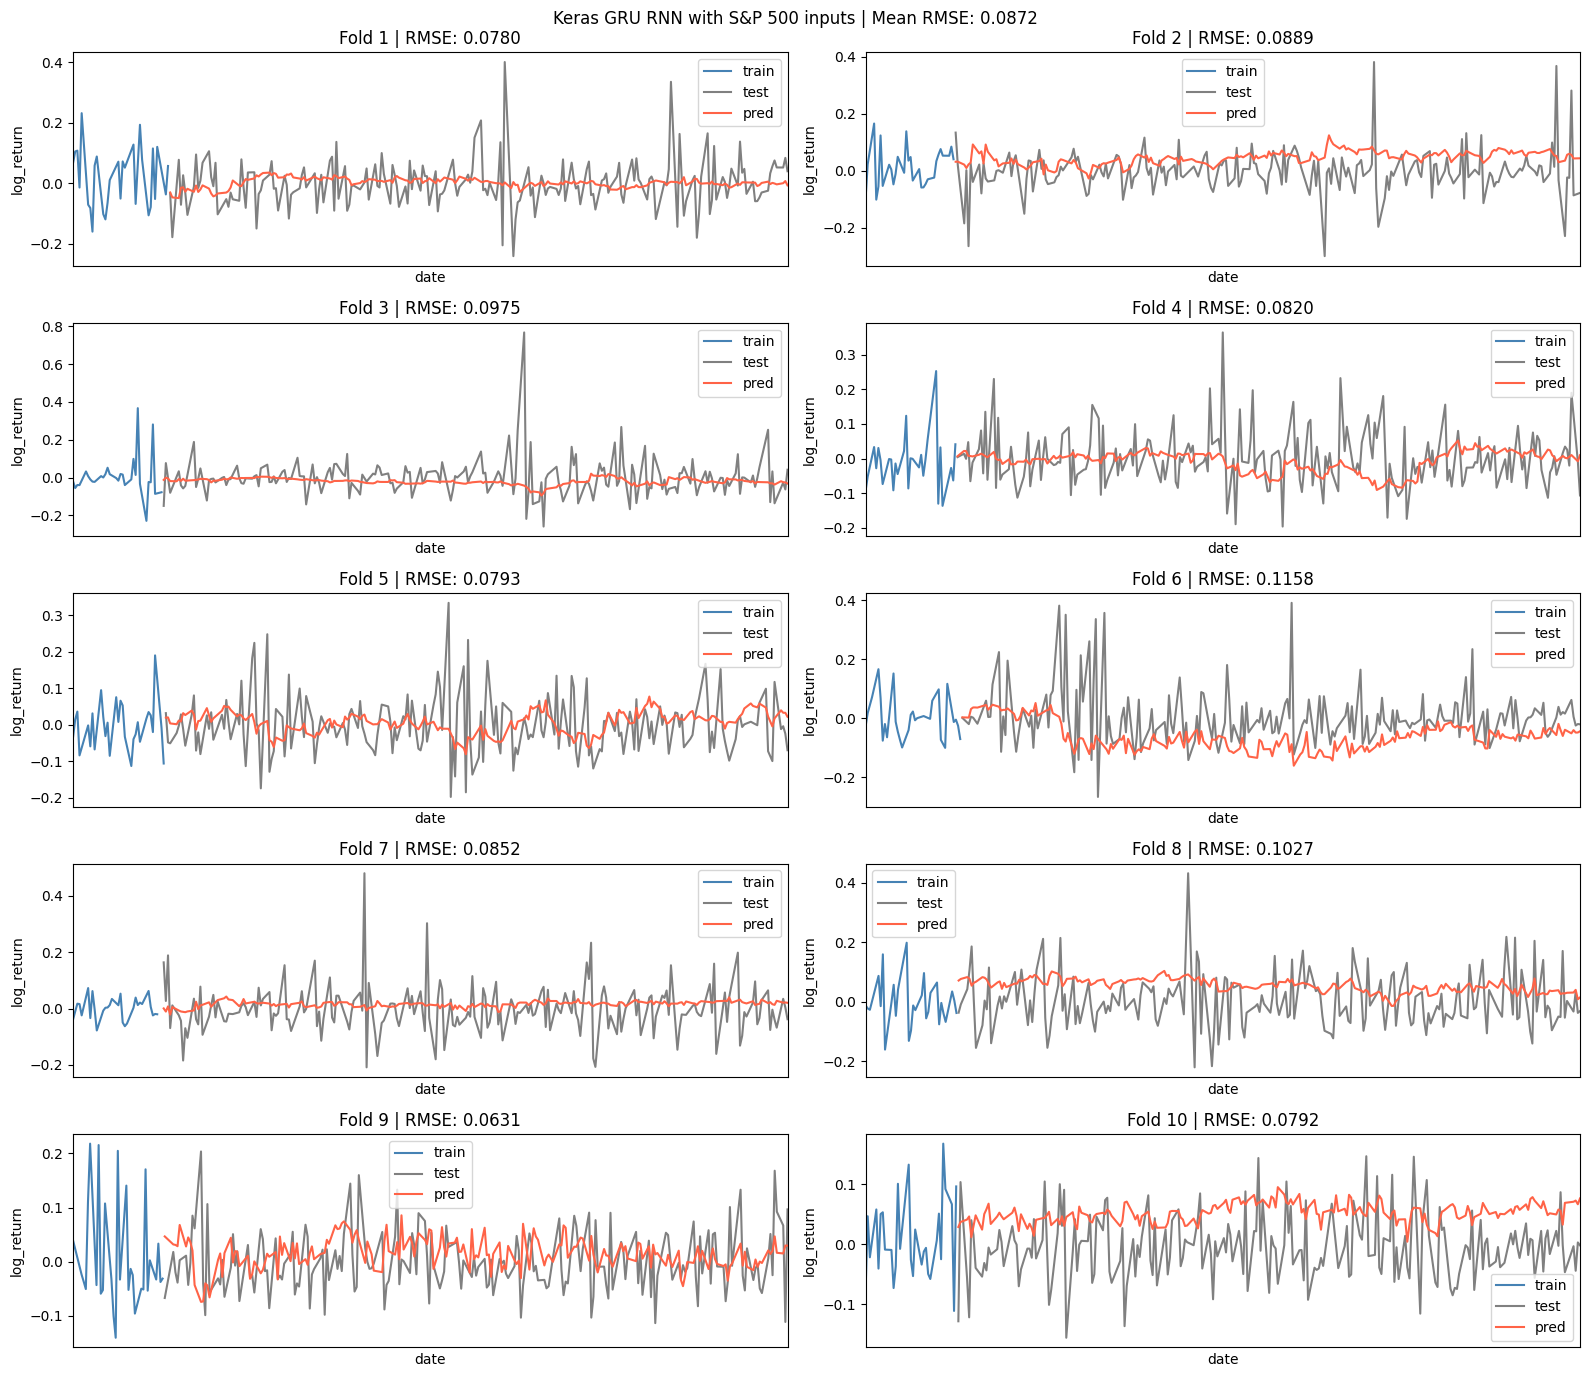

,fold,model,epochs,rmse,mae,r2,directional_accuracy
0,1,keras_gru,14.0,0.078039,0.056129,-0.040608,0.510
1,1,zero_return,NaN,0.076522,0.054432,-0.000542,0.000
2,1,train_mean,NaN,0.076537,0.054472,-0.000937,0.465
3,1,previous_vix_return,NaN,0.114181,0.079502,-1.227637,0.520
4,2,keras_gru,11.0,0.088919,0.067629,-0.437439,0.505
5,2,zero_return,NaN,0.074190,0.047140,-0.000662,0.005
6,2,train_mean,NaN,0.074248,0.047218,-0.002217,0.480
7,2,previous_vix_return,NaN,0.107465,0.072197,-1.099583,0.485
8,3,keras_gru,11.0,0.097524,0.060904,-0.055310,0.560
9,3,zero_return,NaN,0.094934,0.059437,-0.000019,0.005


In [63]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
fold_splits = list(tscv.split(model_df))
n_folds = len(fold_splits)
plot_cols = min(2, max(1, n_folds))
plot_rows = int(np.ceil(n_folds / plot_cols))

fold_metrics = []
fold_predictions = []
fold_histories = []
fold_target_summaries = []
fig, axes = plt.subplots(
    nrows=plot_rows,
    ncols=plot_cols,
    figsize=(8 * plot_cols, 2.8 * plot_rows),
    squeeze=False,
)
axes = axes.ravel()

for fold, (train_idx, test_idx) in enumerate(fold_splits):
    train_arrays, val_arrays, test_arrays, target_scaler, fold_indices = make_arrays_for_fold(train_idx, test_idx)
    x_train, y_train, _, _ = train_arrays
    x_val, y_val, _, _ = val_arrays
    x_test, _, y_test_raw, test_target_indices = test_arrays

    for split_name, indices in [
        ("train", fold_indices["fit_target_indices"]),
        ("validation", fold_indices["val_target_indices"]),
        ("test", fold_indices["test_target_indices"]),
    ]:
        values = model_df.iloc[indices][TARGET_COL].to_numpy(dtype=np.float64)
        fold_target_summaries.append({
            "fold": fold + 1,
            "split": split_name,
            "rows": len(values),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        })

    keras.backend.clear_session()
    tf.random.set_seed(RANDOM_SEED + fold)
    model = build_keras_rnn(input_shape=(LOOKBACK_DAYS, len(FEATURE_COLS)))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            min_delta=1e-5,
            restore_best_weights=True,
        )
    ]

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )
    fold_history = pd.DataFrame({
        "fold": fold + 1,
        "epoch": np.arange(1, len(history.history["loss"]) + 1),
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
    })
    fold_histories.append(fold_history)

    pred_scaled = model.predict(x_test, verbose=0).reshape(-1)
    test_metrics, preds = evaluate_predictions(pred_scaled, y_test_raw, test_target_indices, target_scaler)
    preds["fold"] = fold + 1
    fold_predictions.append(preds)
    fold_metrics.append({"fold": fold + 1, "model": "keras_gru", "epochs": len(history.history["loss"]), **test_metrics})

    train_target_values = model_df.iloc[fold_indices["fit_target_indices"]][TARGET_COL].to_numpy(dtype=np.float64)
    baseline_predictions = {
        "zero_return": np.zeros_like(y_test_raw, dtype=np.float64),
        "train_mean": np.full_like(y_test_raw, train_target_values.mean(), dtype=np.float64),
        "previous_vix_return": model_df.iloc[test_target_indices]["vix_log_return_lag1"].to_numpy(dtype=np.float64),
    }
    for baseline_name, baseline_pred in baseline_predictions.items():
        fold_metrics.append({
            "fold": fold + 1,
            "model": baseline_name,
            "epochs": np.nan,
            **regression_metrics(y_test_raw, baseline_pred),
        })

    ax = axes[fold]
    train_show_idx = train_idx[-30:]
    sns.lineplot(
        x=model_df["date"].iloc[train_show_idx],
        y=model_df[TARGET_COL].iloc[train_show_idx],
        label="train",
        color="steelblue",
        ax=ax,
    )
    sns.lineplot(x=preds["date"], y=preds["actual"], label="test", color="grey", ax=ax)
    sns.lineplot(x=preds["date"], y=preds["predicted"], label="pred", color="tomato", ax=ax)
    ax.set_xlim([model_df["date"].iloc[train_show_idx[0]], preds["date"].iloc[-1]])
    ax.set_xticks([])
    ax.set_title(f"Fold {fold + 1} | RMSE: {test_metrics['rmse']:.4f}")
    ax.legend()

for ax in axes[n_folds:]:
    ax.set_visible(False)

metrics_df = pd.DataFrame(fold_metrics)
predictions_df = pd.concat(fold_predictions, ignore_index=True)
history_df = pd.concat(fold_histories, ignore_index=True)
target_summary_df = pd.DataFrame(fold_target_summaries)
mean_gru_rmse = metrics_df.loc[metrics_df["model"].eq("keras_gru"), "rmse"].mean()

plt.suptitle(f"Keras GRU RNN with S&P 500 inputs | Mean RMSE: {mean_gru_rmse:.4f}")
plt.tight_layout()
plt.show()

metrics_df

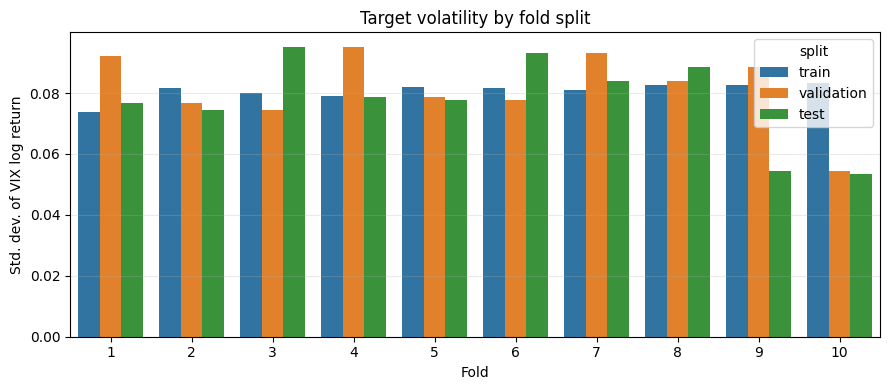

,fold,split,rows,mean,std,min,max
0,1,train,303,0.000560,0.073853,-0.192642,0.279008
1,1,validation,200,0.003134,0.092204,-0.201162,0.381495
2,1,test,200,-0.001782,0.076694,-0.240590,0.401011
3,2,train,503,0.001584,0.081566,-0.201162,0.381495
4,2,validation,200,-0.001782,0.076694,-0.240590,0.401011
5,2,test,200,-0.001908,0.074352,-0.299831,0.381070
6,3,train,703,0.000626,0.080170,-0.240590,0.401011
7,3,validation,200,-0.001908,0.074352,-0.299831,0.381070
8,3,test,200,-0.000419,0.095172,-0.259645,0.768245
9,4,train,903,0.000065,0.078885,-0.299831,0.401011


In [64]:
if "target_summary_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so target_summary_df is available.")

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=target_summary_df, x="fold", y="std", hue="split", ax=ax)
ax.set_title("Target volatility by fold split")
ax.set_xlabel("Fold")
ax.set_ylabel("Std. dev. of VIX log return")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

target_summary_df


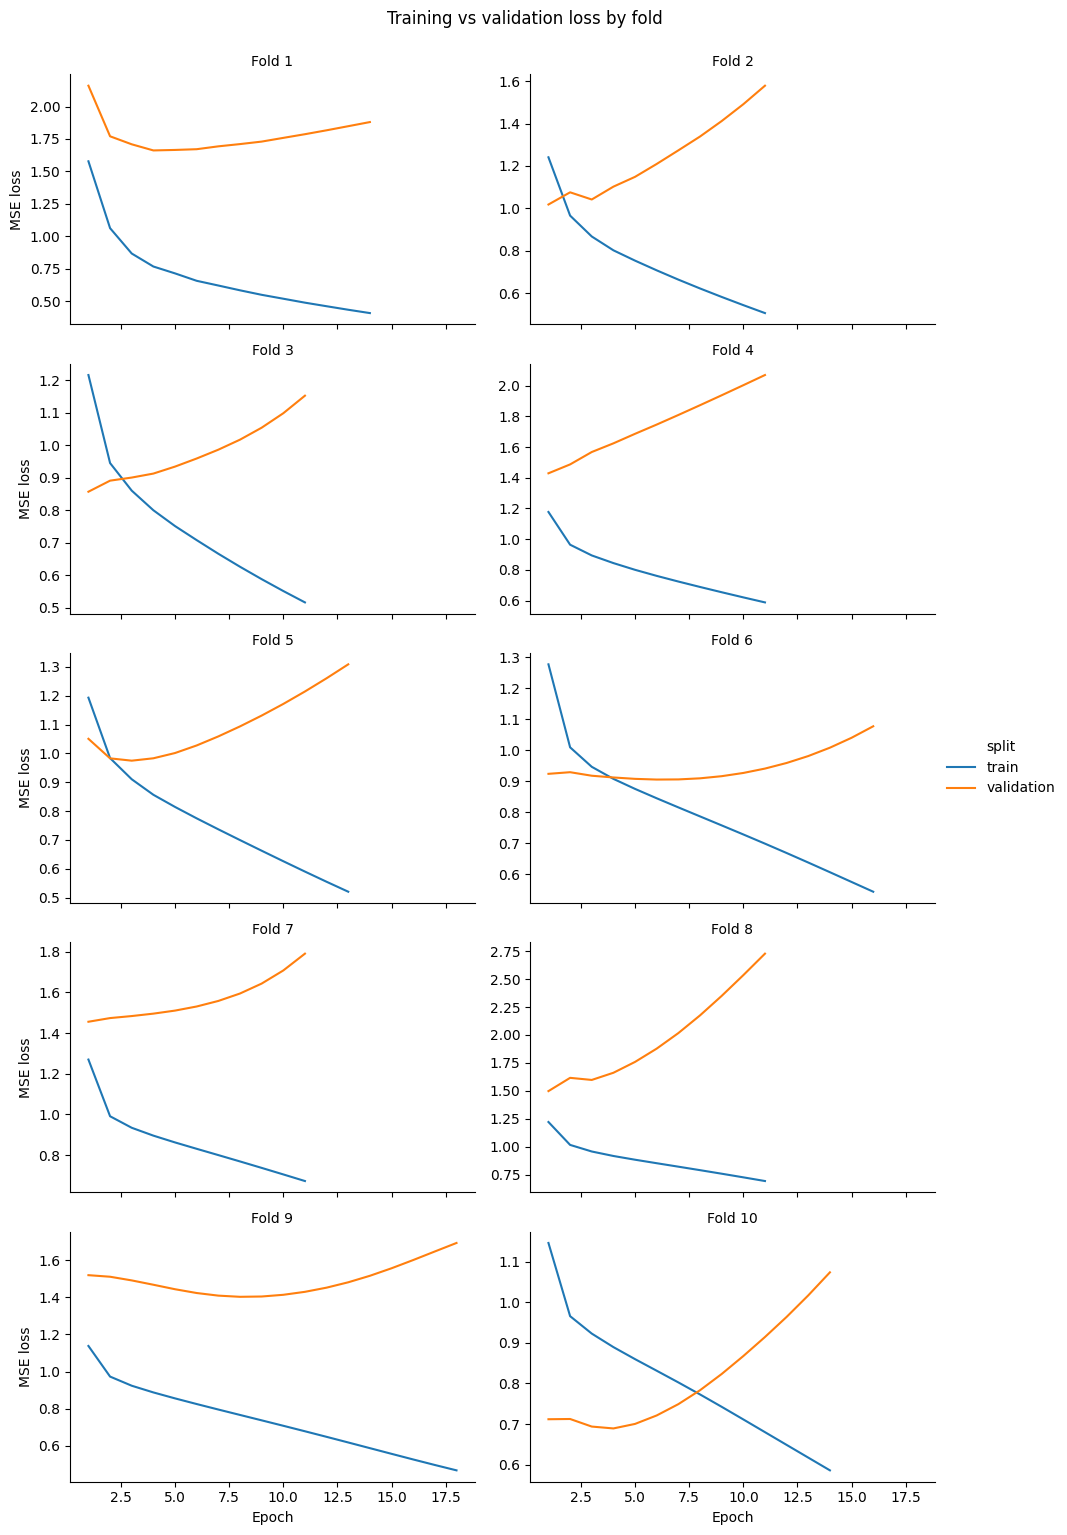

,fold,epoch,train_loss,val_loss
0,1,14,0.408710,1.880472
1,2,11,0.505867,1.578833
2,3,11,0.515906,1.152585
3,4,11,0.588232,2.069252
4,5,13,0.520649,1.309143
5,6,16,0.543701,1.076791
6,7,11,0.672872,1.790771
7,8,11,0.693345,2.727232
8,9,18,0.468639,1.692720
9,10,14,0.586154,1.073656


In [65]:
if "history_df" not in globals():
    raise RuntimeError("Run the walk-forward evaluation cell first so history_df is available.")

loss_long = history_df.melt(
    id_vars=["fold", "epoch"],
    value_vars=["train_loss", "val_loss"],
    var_name="split",
    value_name="loss",
)
loss_long["split"] = loss_long["split"].map({"train_loss": "train", "val_loss": "validation"})
loss_col_wrap = min(2, max(1, history_df["fold"].nunique()))

g = sns.relplot(
    data=loss_long,
    x="epoch",
    y="loss",
    hue="split",
    col="fold",
    col_wrap=loss_col_wrap,
    kind="line",
    height=3,
    aspect=1.6,
    facet_kws={"sharey": False},
)
g.set_titles("Fold {col_name}")
g.set_axis_labels("Epoch", "MSE loss")
g.fig.suptitle("Training vs validation loss by fold", y=1.02)
plt.show()

history_df.groupby("fold").tail(1).reset_index(drop=True)


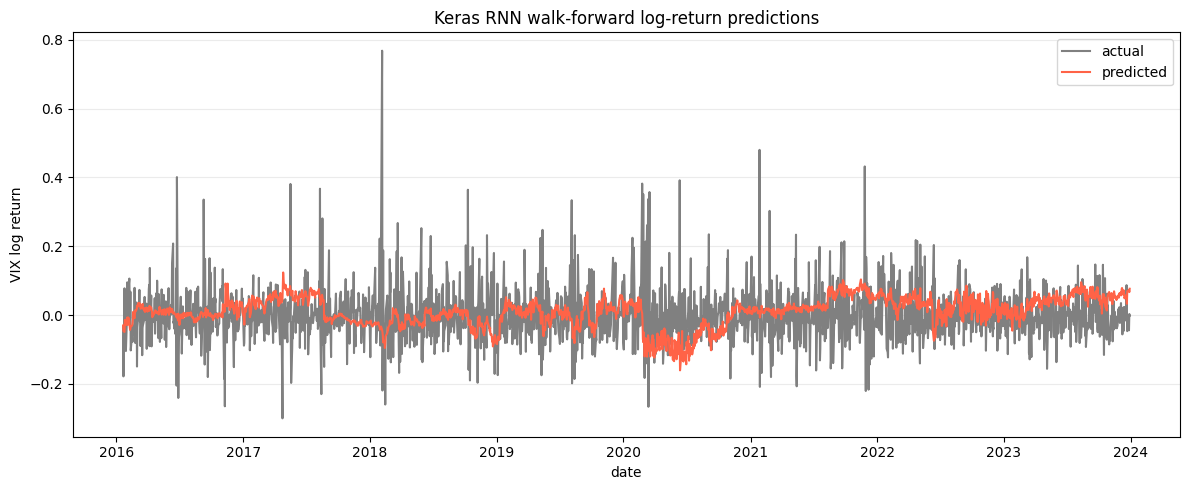

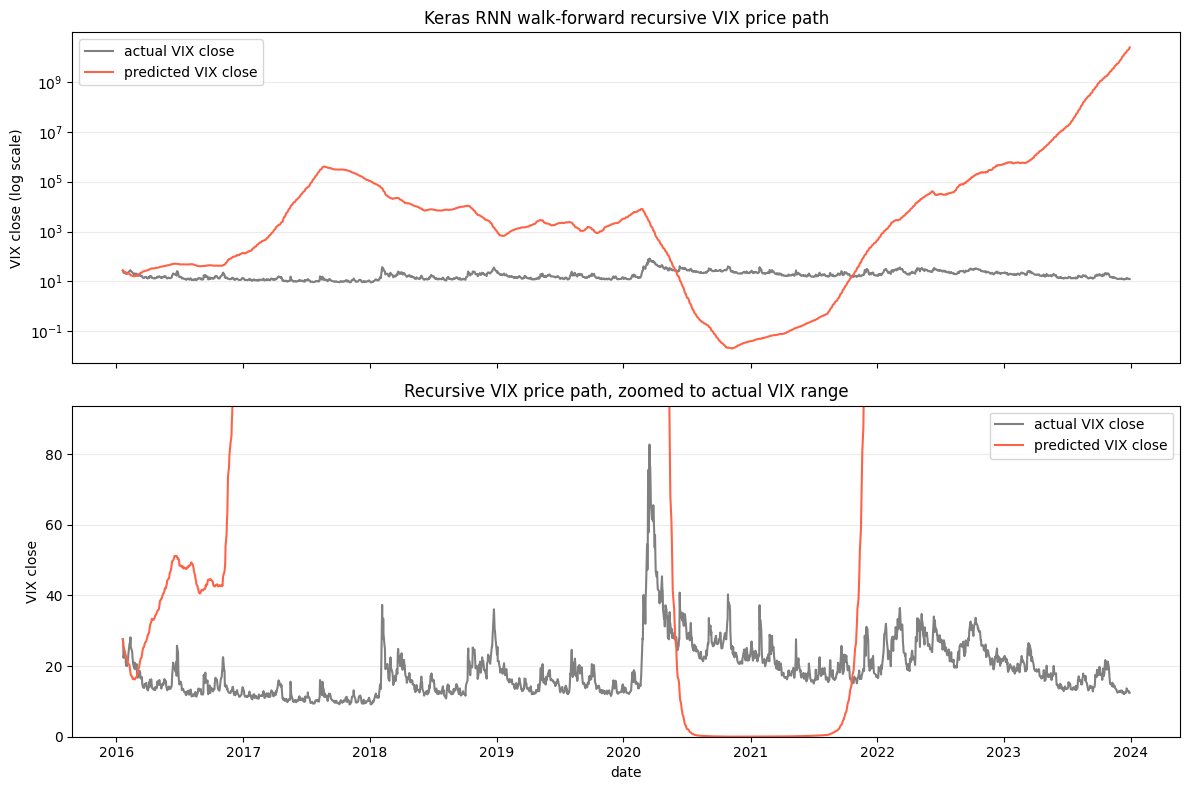

,model,mean_rmse,mean_mae,mean_r2,mean_directional_accuracy
3,zero_return,0.077436,0.054865,-0.001005,0.0040
2,train_mean,0.077444,0.054897,-0.001275,0.4565
0,keras_gru,0.087178,0.065259,-0.318012,0.5015
1,previous_vix_return,0.114251,0.080869,-1.175381,0.4865


Keras GRU mean log-return RMSE: 0.0872
Keras GRU mean log-return MAE: 0.0653
Keras GRU recursive VIX price RMSE: 1582132590.6988
Keras GRU recursive VIX price MAE: 210166291.6627
Keras GRU one-day anchored VIX price RMSE: 2.1703
Keras GRU one-day anchored VIX price MAE: 1.3113
Max actual price reconstruction error from one-day log returns: 0.00001052
Max actual price reconstruction error from cumulative log returns: 0.00000809


,date,actual_vix_price,predicted_vix_price,predicted_vix_price_one_day,actual_simple_return,predicted_simple_return,fold
0,2016-01-21,26.690001,26.770458,26.770458,-0.032621,-0.029704,1
1,2016-01-22,22.340000,25.555058,25.478253,-0.162982,-0.045401,1
2,2016-01-25,24.150000,24.339007,21.276940,0.081021,-0.047586,1
3,2016-01-26,22.500000,23.991873,23.805560,-0.068323,-0.014262,1
4,2016-01-27,23.110001,23.674244,22.202123,0.027111,-0.013239,1


In [69]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=predictions_df, x="date", y="actual", label="actual", color="grey", ax=ax)
sns.lineplot(data=predictions_df, x="date", y="predicted", label="predicted", color="tomato", ax=ax)
ax.set_title("Keras RNN walk-forward log-return predictions")
ax.set_xlabel("date")
ax.set_ylabel("VIX log return")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

required_price_cols = {"adjclose"}
missing_price_cols = sorted(required_price_cols.difference(model_df.columns))
if missing_price_cols:
    raise ValueError(f"model_df is missing price columns needed for price reconstruction: {missing_price_cols}")

price_predictions_df = (
    predictions_df.copy()
    .sort_values(["target_index", "fold"])
    .drop_duplicates(subset=["target_index"], keep="last")
    .sort_values("target_index")
    .reset_index(drop=True)
)

target_positions = price_predictions_df["target_index"].to_numpy(dtype=int)
previous_target_positions = target_positions - 1
if len(target_positions) == 0:
    raise ValueError("predictions_df is empty; run the walk-forward evaluation cell first.")
if np.any(previous_target_positions < 0):
    raise ValueError("Cannot build price predictions without a prior VIX close for every target row.")

price_predictions_df["date"] = model_df.iloc[target_positions]["date"].to_numpy()
price_predictions_df["actual_vix_price"] = model_df.iloc[target_positions]["adjclose"].to_numpy(dtype=np.float64)
price_predictions_df["previous_actual_vix_price"] = model_df.iloc[previous_target_positions]["adjclose"].to_numpy(dtype=np.float64)
price_predictions_df["actual_simple_return"] = np.expm1(price_predictions_df["actual"])
price_predictions_df["predicted_simple_return"] = np.expm1(price_predictions_df["predicted"])
price_predictions_df["actual_vix_price_from_return"] = (
    price_predictions_df["previous_actual_vix_price"] * np.exp(price_predictions_df["actual"])
)
price_predictions_df["predicted_vix_price_one_day"] = (
    price_predictions_df["previous_actual_vix_price"] * np.exp(price_predictions_df["predicted"])
)

anchor_index = int(previous_target_positions[0])
anchor_row = model_df.iloc[anchor_index]
anchor_date = anchor_row["date"]
anchor_price = float(anchor_row["adjclose"])

actual_path_prices = []
predicted_path_prices = []
previous_actual_path_price = anchor_price
previous_predicted_path_price = anchor_price
for actual_log_return, predicted_log_return in zip(
    price_predictions_df["actual"].to_numpy(dtype=np.float64),
    price_predictions_df["predicted"].to_numpy(dtype=np.float64),
):
    previous_actual_path_price = previous_actual_path_price * np.exp(actual_log_return)
    previous_predicted_path_price = previous_predicted_path_price * np.exp(predicted_log_return)
    actual_path_prices.append(previous_actual_path_price)
    predicted_path_prices.append(previous_predicted_path_price)

price_predictions_df["actual_vix_price_from_path"] = actual_path_prices
price_predictions_df["predicted_vix_price"] = predicted_path_prices

non_consecutive_targets = price_predictions_df["target_index"].diff().dropna().ne(1)
if non_consecutive_targets.any():
    print(
        "Warning: predicted target rows are not consecutive; "
        "the recursive price path compounds across available predicted rows."
    )

price_plot_df = pd.concat(
    [
        pd.DataFrame(
            {
                "date": [anchor_date],
                "actual_vix_price": [anchor_price],
                "predicted_vix_price": [anchor_price],
            }
        ),
        price_predictions_df[["date", "actual_vix_price", "predicted_vix_price"]],
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
for ax in axes:
    ax.plot(price_plot_df["date"], price_plot_df["actual_vix_price"], label="actual VIX close", color="grey")
    ax.plot(price_plot_df["date"], price_plot_df["predicted_vix_price"], label="predicted VIX close", color="tomato")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()

axes[0].set_yscale("log")
axes[0].set_title("Keras RNN walk-forward recursive VIX price path")
axes[0].set_ylabel("VIX close (log scale)")

actual_min = price_plot_df["actual_vix_price"].min()
actual_max = price_plot_df["actual_vix_price"].max()
actual_padding = max((actual_max - actual_min) * 0.15, 1.0)
axes[1].set_ylim(max(0, actual_min - actual_padding), actual_max + actual_padding)
axes[1].set_title("Recursive VIX price path, zoomed to actual VIX range")
axes[1].set_xlabel("date")
axes[1].set_ylabel("VIX close")
plt.tight_layout()
plt.show()

model_summary = (
    metrics_df.groupby("model", as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_r2=("r2", "mean"),
        mean_directional_accuracy=("directional_accuracy", "mean"),
    )
    .sort_values("mean_rmse")
)
display(model_summary)

keras_rows = metrics_df[metrics_df["model"].eq("keras_gru")]
recursive_price_metrics = regression_metrics(
    price_predictions_df["actual_vix_price"],
    price_predictions_df["predicted_vix_price"],
)
one_day_price_metrics = regression_metrics(
    price_predictions_df["actual_vix_price"],
    price_predictions_df["predicted_vix_price_one_day"],
)
one_day_reconstruction_error = (
    price_predictions_df["actual_vix_price"] - price_predictions_df["actual_vix_price_from_return"]
).abs().max()
path_reconstruction_error = (
    price_predictions_df["actual_vix_price"] - price_predictions_df["actual_vix_price_from_path"]
).abs().max()
print(f"Keras GRU mean log-return RMSE: {keras_rows['rmse'].mean():.4f}")
print(f"Keras GRU mean log-return MAE: {keras_rows['mae'].mean():.4f}")
print(f"Keras GRU recursive VIX price RMSE: {recursive_price_metrics['rmse']:.4f}")
print(f"Keras GRU recursive VIX price MAE: {recursive_price_metrics['mae']:.4f}")
print(f"Keras GRU one-day anchored VIX price RMSE: {one_day_price_metrics['rmse']:.4f}")
print(f"Keras GRU one-day anchored VIX price MAE: {one_day_price_metrics['mae']:.4f}")
print(f"Max actual price reconstruction error from one-day log returns: {one_day_reconstruction_error:.8f}")
print(f"Max actual price reconstruction error from cumulative log returns: {path_reconstruction_error:.8f}")
price_predictions_df[
    [
        "date",
        "actual_vix_price",
        "predicted_vix_price",
        "predicted_vix_price_one_day",
        "actual_simple_return",
        "predicted_simple_return",
        "fold",
    ]
].head()